# Levenshtein distance

In [17]:
def lev_dist(str1: str, str2: str) -> int:
    """
    Returns the levenshtein distance between two strings
    IMPORTANT: It's case sensitive and non-conmutative.

    The levenshtein distance is the minimum number of inserts,
    substitution or deletion of single characters in a string
    to match another string.
    """

    dist = [[0 for n in str2] for m in str1]
    # dist = [[0] * (len(str2) + 1) for _ in range(len(str1) + 1)]

    for i in range(1, len(str1)):
        dist[i][0] = i

    for j in range(1, len(str2)):
        dist[0][j] = j

    for j in range(1, len(str2)):
        for i in range(1, len(str1)):
            cost = 0 if str1[i] == str2[j] else 1
        
            dist[i][j] = min(dist[i-1][j] + 1, dist[i][j-1] + 1, dist[i-1][j-1] + cost)

    print(dist)
    return dist[-1][-1]

# Baseline

Código de ejemplo que muestra como procesar y extraer texto con un OCR.

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


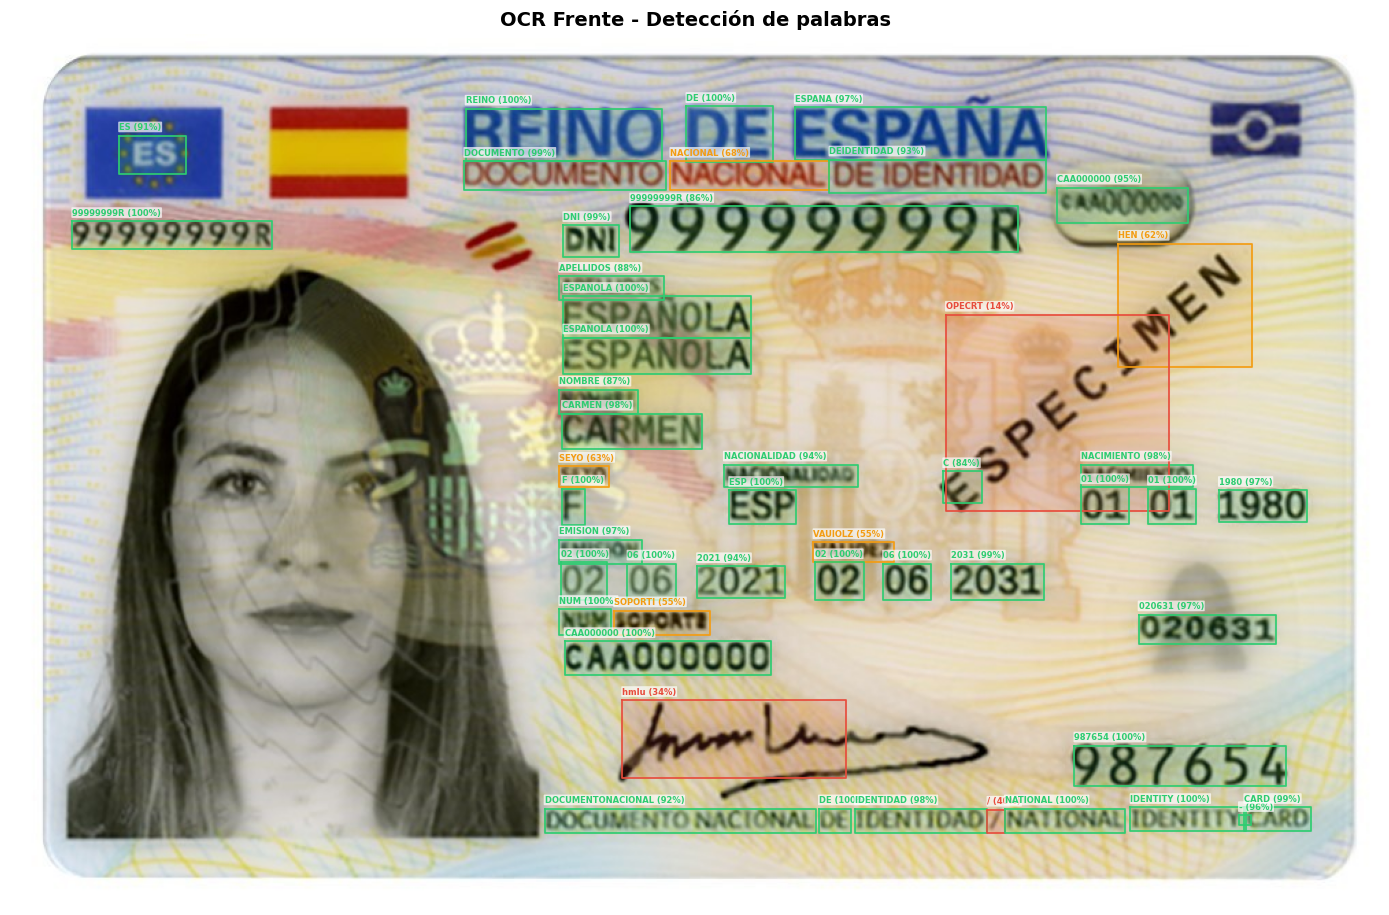

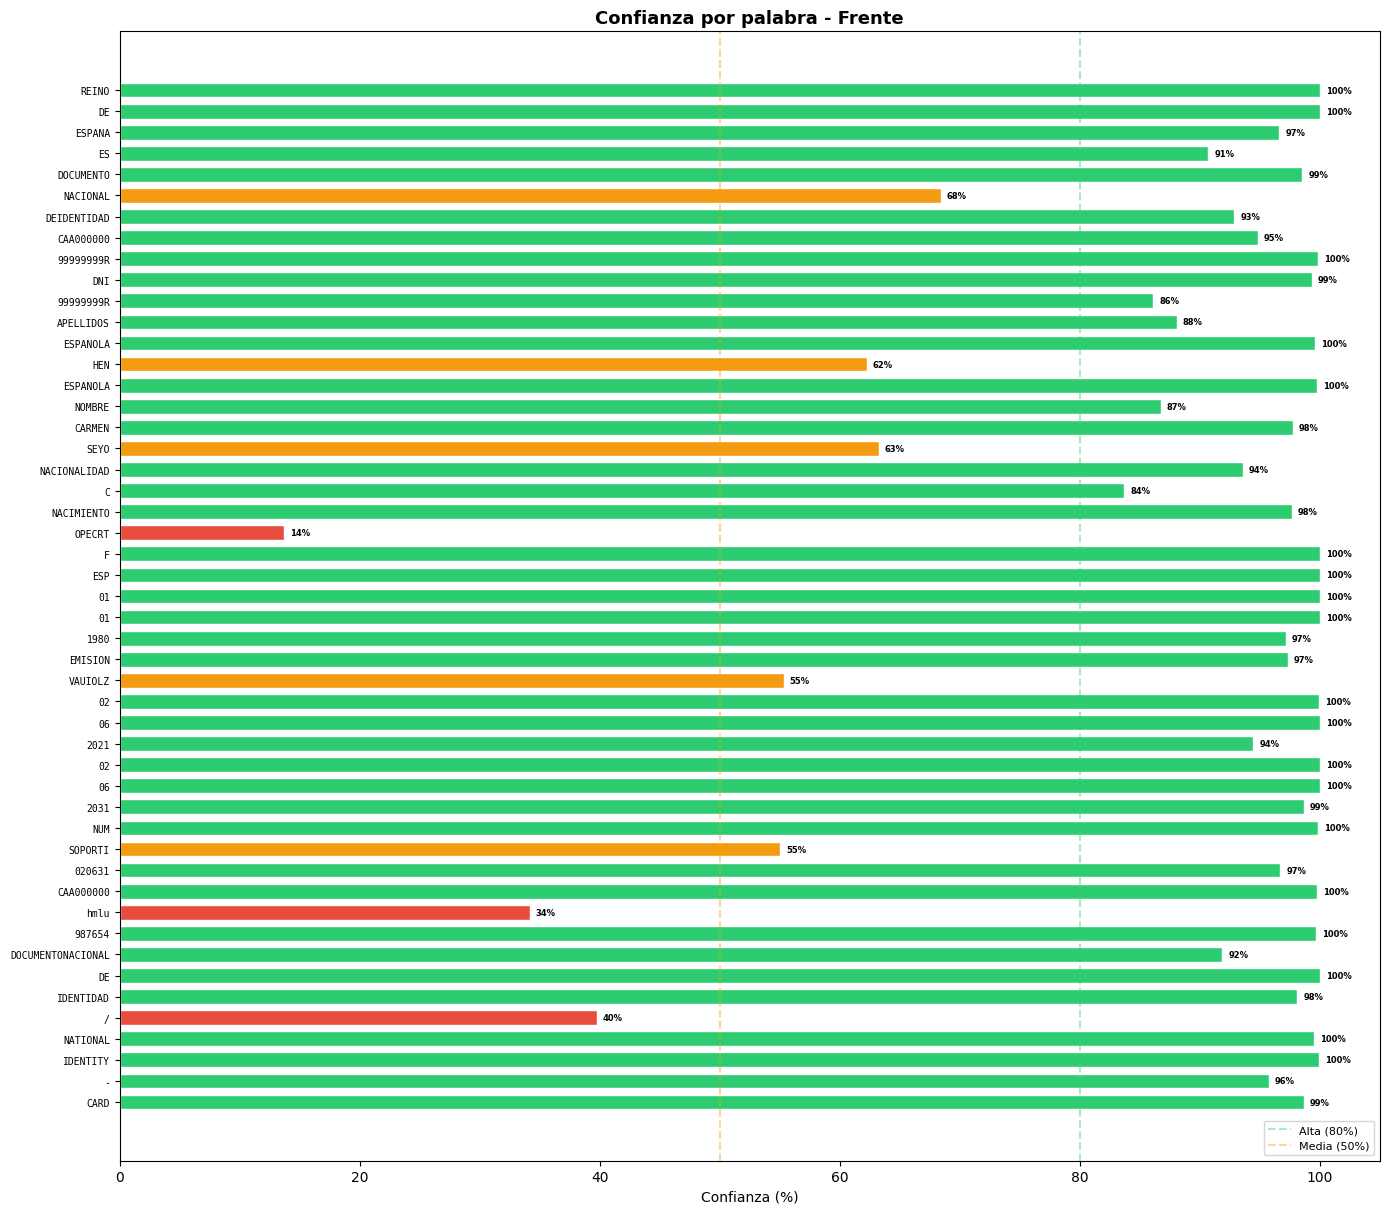

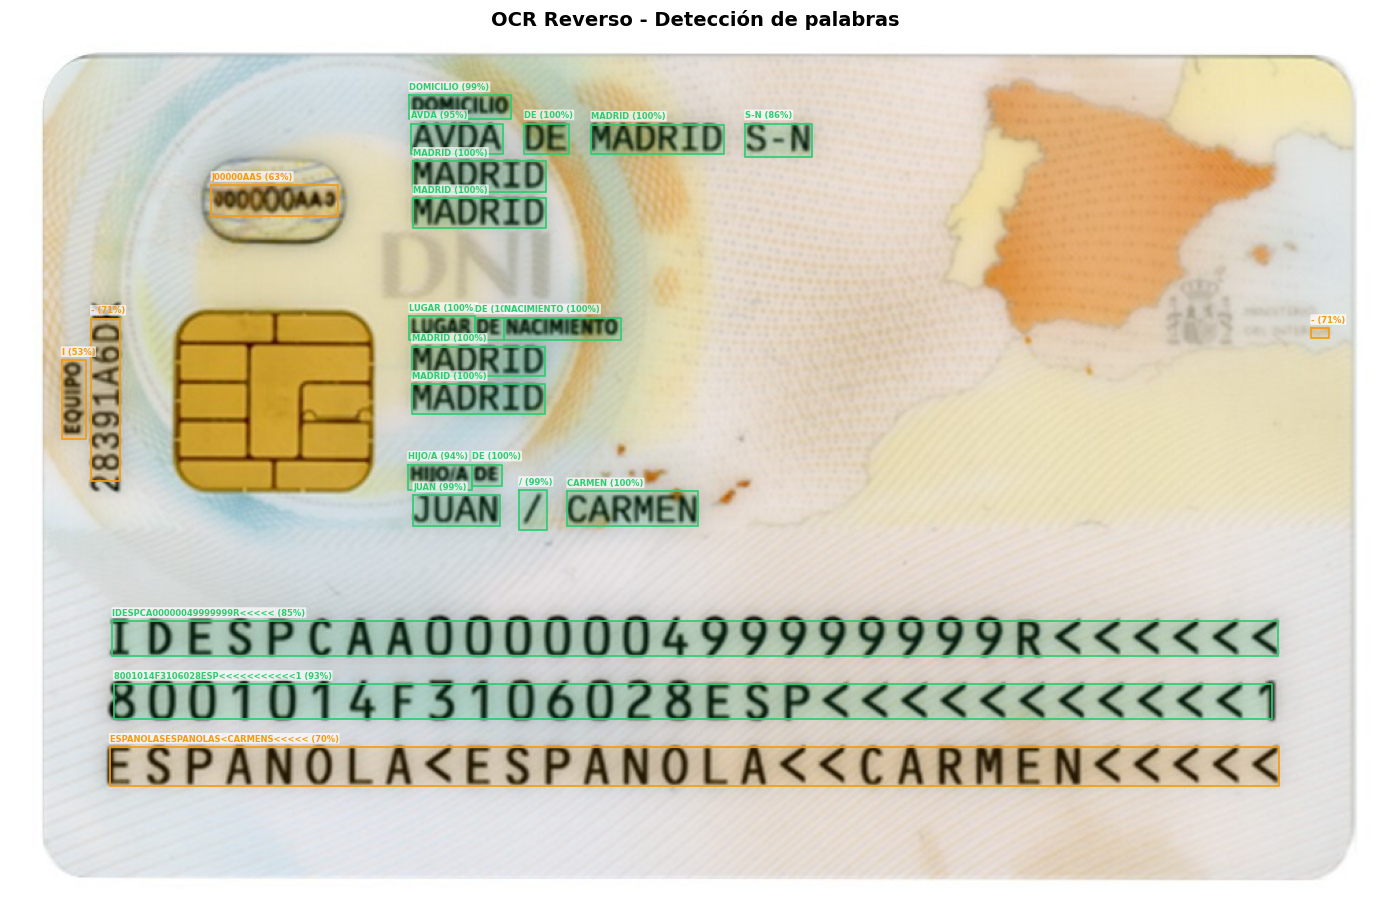

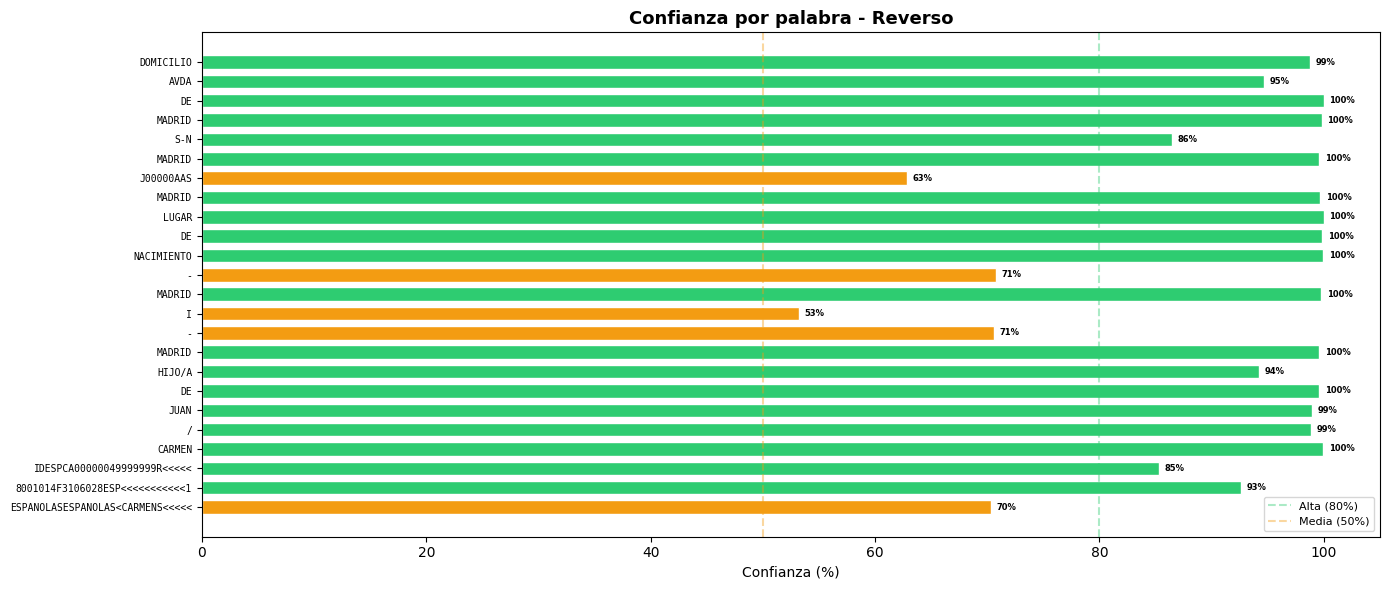


  RESULTADO DEL ANALISIS DNI

                       DATOS PERSONALES                     
  --------------------------------------------------------------
  Numero DNI:        99999999R
  Apellidos:         Espanola Espanola
  Nombre:            Carmen
  Nombre completo:   Carmen Espanola Espanola
  Sexo:              Femenino
  Nacionalidad:      ESP

                            FECHAS                          
  --------------------------------------------------------------
  Nacimiento:        01/01/1980
  Emision:           02/06/2021
  Expiracion:        02/06/1931

                      DATOS ADICIONALES                     
  --------------------------------------------------------------
  Domicilio:         AVDA DE MADRID S-N, MADRID
  Lugar nacim.:      MADRID
  Hijo/a de:         JUAN / CARMEN
  N. Soporte:        CAA000000

                             MRZ                            
  --------------------------------------------------------------
  Tipo:              ID
 

In [3]:
%pip install python-doctr[torch]

import re, json
from datetime import date
from dataclasses import dataclass, field
from typing import Optional, List
import matplotlib.pyplot as plt
from matplotlib import patches
import matplotlib.image as mpimg
from doctr.io import DocumentFile
from doctr.models import ocr_predictor

model = ocr_predictor(pretrained=True)

# ── Dataclasses ──

@dataclass
class MRZData:
    raw_lines: List[str] = field(default_factory=list)
    document_type: str = ""
    country_code: str = ""
    document_number: str = ""
    doc_check_valid: bool = False
    optional_data_1: str = ""
    birth_date: str = ""
    birth_check_valid: bool = False
    sex: str = ""
    expiry_date: str = ""
    expiry_check_valid: bool = False
    nationality: str = ""
    optional_data_2: str = ""
    composite_check_valid: bool = False
    surname: str = ""
    given_names: str = ""
    all_checksums_valid: bool = False

@dataclass
class FrontData:
    dni_number: str = ""
    surname: str = ""
    given_names: str = ""
    sex: str = ""
    nationality: str = ""
    birth_date: str = ""
    issue_date: str = ""
    expiry_date: str = ""
    support_number: str = ""

@dataclass
class DNIResult:
    dni_number: str = ""
    surname: str = ""
    given_names: str = ""
    full_name: str = ""
    sex: str = ""
    nationality: str = ""
    birth_date: str = ""
    issue_date: str = ""
    expiry_date: str = ""
    domicilio: str = ""
    lugar_nacimiento: str = ""
    padres: str = ""
    support_number: str = ""
    front: Optional[FrontData] = None
    mrz: Optional[MRZData] = None
    # Análisis
    ocr_confidence_front: float = 0.0
    ocr_confidence_back: float = 0.0
    dni_letter_valid: Optional[bool] = None
    document_expired: Optional[bool] = None
    days_to_expiry: Optional[int] = None
    data_completeness: float = 0.0
    cross_validation: dict = field(default_factory=dict)
    risk_flags: List[str] = field(default_factory=list)
    quality_score: float = 0.0
    raw_front_text: List[str] = field(default_factory=list)
    raw_back_text: List[str] = field(default_factory=list)

# ── Visualización OCR con matplotlib ──

def show_ocr(result, img_path, title="OCR"):
    """Muestra la imagen con bounding boxes coloreados por confianza y texto con %"""
    img = mpimg.imread(img_path)
    h, w = img.shape[:2]

    for page in result.pages:
        fig, ax = plt.subplots(1, figsize=(14, 10))
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold')

        for block in page.blocks:
            for line in block.lines:
                for word in line.words:
                    (x1, y1), (x2, y2) = word.geometry
                    # Coordenadas normalizadas → píxeles
                    px1, py1, px2, py2 = x1*w, y1*h, x2*w, y2*h
                    conf = word.confidence

                    # Color según confianza: verde (alta) → amarillo → rojo (baja)
                    if conf >= 0.8:
                        color = '#2ecc71'      # verde
                    elif conf >= 0.5:
                        color = '#f39c12'      # naranja
                    else:
                        color = '#e74c3c'      # rojo

                    rect = patches.Rectangle(
                        (px1, py1), px2-px1, py2-py1,
                        linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.15)
                    ax.add_patch(rect)
                    ax.plot([px1, px2, px2, px1, px1], [py1, py1, py2, py2, py1],
                            color=color, linewidth=1.2)
                    ax.text(px1, py1-3, f"{word.value} ({conf:.0%})",
                            fontsize=6, color=color, fontweight='bold',
                            va='bottom', bbox=dict(boxstyle='round,pad=0.1',
                            facecolor='white', alpha=0.7, edgecolor='none'))

        ax.axis('off')
        plt.tight_layout()
        plt.show()

def show_confidence_chart(result, title="Confianza por palabra"):
    """Gráfico de barras con la confianza de cada palabra detectada"""
    words, confs = [], []
    for page in result.pages:
        for block in page.blocks:
            for line in block.lines:
                for w in line.words:
                    words.append(w.value)
                    confs.append(w.confidence * 100)

    if not words:
        return

    fig, ax = plt.subplots(figsize=(14, max(4, len(words) * 0.25)))
    colors = ['#2ecc71' if c >= 80 else '#f39c12' if c >= 50 else '#e74c3c' for c in confs]
    y_pos = range(len(words))

    ax.barh(y_pos, confs, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=7, fontfamily='monospace')
    ax.set_xlabel('Confianza (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.invert_yaxis()

    # Líneas de referencia
    ax.axvline(x=80, color='#2ecc71', linestyle='--', alpha=0.4, label='Alta (80%)')
    ax.axvline(x=50, color='#f39c12', linestyle='--', alpha=0.4, label='Media (50%)')
    ax.legend(loc='lower right', fontsize=8)

    for i, c in enumerate(confs):
        ax.text(c + 0.5, i, f'{c:.0f}%', va='center', fontsize=6, fontweight='bold')

    plt.tight_layout()
    plt.show()

# ── OCR ──

def ocr_image(path):
    return model(DocumentFile.from_images(path))

def get_lines(result, min_conf=0.2):
    """Devuelve lista de (texto_linea, confianza_media)"""
    data = []
    for page in result.pages:
        for block in page.blocks:
            for line in block.lines:
                words = [(w.value, w.confidence) for w in line.words if w.confidence >= min_conf]
                if words:
                    data.append((' '.join(w for w, _ in words),
                                 sum(c for _, c in words) / len(words)))
    return data

# ── Utils ──

def clean_mrz(line):
    """Deja solo A-Z, 0-9, <"""
    return re.sub(r'[^A-Z0-9<]', '', line.upper().replace(' ', ''))

def norm_name(name):
    """GARCIA<LOPEZ → Garcia Lopez"""
    return re.sub(r'\s+', ' ', re.sub(r'<+', ' ', name)).strip().title()

def levenshtein(s1, s2):
    if len(s1) < len(s2): return levenshtein(s2, s1)
    if not s2: return len(s1)
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        curr = [i + 1]
        for j, c2 in enumerate(s2):
            curr.append(min(prev[j+1]+1, curr[j]+1, prev[j]+(0 if c1==c2 else 1)))
        prev = curr
    return prev[-1]

# ── Validación letra DNI/NIE (mod 23) ──

DNI_LETTERS = "TRWAGMYFPDXBNJZSQVHLCKE"

def validate_dni_letter(dni):
    if not dni: return False
    try:
        n = dni[:-1]
        if n[0] in 'XYZ': n = str('XYZ'.index(n[0])) + n[1:]
        return dni[-1].upper() == DNI_LETTERS[int(n) % 23]
    except (ValueError, IndexError):
        return False

# ── MRZ ICAO 9303 TD1 ──

MRZ_W = [7, 3, 1]
MRZ_V = {'<': 0}
MRZ_V.update({str(i): i for i in range(10)})
MRZ_V.update({chr(65+i): 10+i for i in range(26)})

def mrz_checksum(data):
    return sum(MRZ_V.get(c.upper(), 0) * MRZ_W[i % 3] for i, c in enumerate(data)) % 10

def mrz_check(data, digit):
    try: return str(mrz_checksum(data)) == digit
    except: return False

def parse_mrz_date(raw):
    """YYMMDD → DD/MM/YYYY"""
    try:
        y, m, d = int(raw[:2]), int(raw[2:4]), int(raw[4:6])
        return f"{d:02d}/{m:02d}/{1900+y if y > 30 else 2000+y}"
    except: return ""

def detect_mrz_lines(lines):
    """Busca las 3 líneas MRZ TD1 clasificando por patrón (no por orden)"""
    cands = [clean_mrz(l) for l in lines]
    cands = [c for c in cands if len(c) >= 25 and re.match(r'^[A-Z0-9<]{25,}$', c)]
    if not cands: return []

    l1 = l2 = l3 = None
    for c in cands:
        p = (c + '<'*30)[:30]
        if not l1 and p[0] in 'IAC' and re.match(r'^[IAC][A-Z<]', p):
            l1 = p
        elif not l2 and re.match(r'^\d{6}', p) and p[7] in 'MF<':
            l2 = p
        elif not l3 and '<<' in c:
            l3 = (c + '<'*30)[:30]
    return [l for l in (l1, l2, l3) if l]

# ── Corrección OCR en línea de nombres del MRZ ──
# El OCR a veces lee '<' como S, K o X, rompiendo los separadores

CONFUSED = set('SKX')

def _fuzzy_in(haystack, needle, tol=2):
    h, n = haystack.upper(), needle.upper()
    if n in h: return True
    return any(levenshtein(h[i:i+len(n)], n) <= tol for i in range(len(h)-len(n)+1))

def _fix_surname(raw, front=None):
    """Intenta reconstruir APELLIDO1<APELLIDO2 usando los datos del frente"""
    if front and front.surname:
        parts = front.surname.upper().split()
        if len(parts) >= 2:
            found, rest = [], raw.upper()
            for p in parts:
                idx = rest.find(p)
                if idx < 0:
                    candidates = range(max(0, len(rest)-len(p)+1))
                    best = min(candidates, key=lambda i: levenshtein(rest[i:i+len(p)], p), default=-1)
                    if best >= 0 and levenshtein(rest[best:best+len(p)], p) <= 2:
                        idx = best
                    else: continue
                found.append(p)
                rest = rest[idx+len(p):].lstrip(''.join(CONFUSED)+'<')
            if found: return '<'.join(found)
    # Sin referencia: separar donde haya char confuso entre letras
    r = raw
    for ch in CONFUSED:
        r = re.sub(r'([A-Z])' + ch + r'([A-Z])', r'\1<\2', r)
    return r

def _fix_name(raw, front=None):
    if front and front.given_names:
        fn = front.given_names.upper()
        if raw.upper().startswith(fn): return fn
    return raw.rstrip(''.join(CONFUSED))

def fix_mrz_names(line3, front=None):
    """Corrige la línea 3 del MRZ donde '<' se confunde con S/K/X"""
    stripped = line3.rstrip('<')

    # Si '<<' está intacto, solo limpiar los nombres
    if '<<' in stripped:
        sur, name = stripped.split('<<', 1)
        name = name.rstrip('<')
        if front and front.given_names and name and _fuzzy_in(name, front.given_names.upper()):
            return (_fix_surname(sur, front) + '<<' + _fix_name(name, front) + '<'*30)[:30]
        return line3

    # '<<' destruido → buscar el nombre del frente dentro del string
    if front and front.given_names:
        fn = front.given_names.upper()
        idx = stripped.upper().find(fn)
        if idx >= 0:
            sur = stripped[:idx].rstrip(''.join(CONFUSED))
            return (_fix_surname(sur, front) + '<<' + fn + '<'*30)[:30]

    # Heurística: '<' al lado de un char confuso
    for i, c in enumerate(stripped):
        if c == '<' and 0 < i < len(stripped)-1:
            if stripped[i-1] in CONFUSED:
                return (_fix_surname(stripped[:i-1], front) + '<<' + stripped[i+1:] + '<'*30)[:30]
            if stripped[i+1] in CONFUSED:
                return (_fix_surname(stripped[:i], front) + '<<' + stripped[i+2:] + '<'*30)[:30]
    return line3

def parse_mrz(lines, front=None):
    """Parsea las 3 líneas MRZ en formato TD1 (30 chars cada una)"""
    if len(lines) < 3: return None

    mrz = MRZData(raw_lines=lines[:3])
    l1, l2 = lines[0], lines[1]
    l3 = fix_mrz_names(lines[2], front)

    # L1: tipo(2) + país(3) + docNum(9) + check(1) + opcional(15)
    mrz.document_type = l1[0:2].replace('<', '')
    mrz.country_code = l1[2:5].replace('<', '')
    mrz.document_number = l1[5:14].replace('<', '')
    mrz.doc_check_valid = mrz_check(l1[5:14], l1[14])
    mrz.optional_data_1 = l1[15:30].replace('<', ' ').strip()

    # L2: nacim(6)+chk(1)+sexo(1)+expir(6)+chk(1)+nac(3)+opc(11)+chkComp(1)
    mrz.birth_date = parse_mrz_date(l2[0:6])
    mrz.birth_check_valid = mrz_check(l2[0:6], l2[6])
    mrz.sex = l2[7] if l2[7] in 'MF' else ''
    mrz.expiry_date = parse_mrz_date(l2[8:14])
    mrz.expiry_check_valid = mrz_check(l2[8:14], l2[14])
    mrz.nationality = l2[15:18].replace('<', '')
    mrz.optional_data_2 = l2[18:29].replace('<', ' ').strip()
    mrz.composite_check_valid = mrz_check(l1[5:30] + l2[0:7] + l2[8:15] + l2[18:29], l2[29])

    # L3: apellidos<<nombre
    parts = l3.rstrip('<').split('<<')
    mrz.surname = norm_name(parts[0])
    if len(parts) >= 2:
        mrz.given_names = norm_name('<<'.join(parts[1:]))

    mrz.all_checksums_valid = all([mrz.doc_check_valid, mrz.birth_check_valid,
                                   mrz.expiry_check_valid, mrz.composite_check_valid])
    return mrz

# ── Extracción del frente ──

STOP_KW = {'NOMBRE', 'SEXO', 'SEYO', 'NACIMIENTO', 'NACIONALIDAD',
            'EMISION', 'VALIDEZ', 'SOPORT', 'DOCUMENTO', 'DNI'}

def _valid(text, min_len=3):
    return len(text) >= min_len and sum(c.isalpha() for c in text) / max(len(text), 1) >= 0.8

def _is_stop(text):
    return any(k in text.upper() for k in STOP_KW)

def extract_front(lines):
    """Extrae los campos del frente buscando etiquetas (APELLIDOS, NOMBRE, etc.)"""
    f = FrontData()

    for line in lines:
        m = re.search(r'(\d{8}[A-Z]|[XYZ]\d{7}[A-Z])', line.upper().replace(' ', ''))
        if m: f.dni_number = m.group(1); break

    for i, line in enumerate(lines):
        up = line.upper().strip()

        if 'APELLIDO' in up:
            parts = []
            for j in range(i+1, min(i+6, len(lines))):
                v = lines[j].strip()
                if _is_stop(v): break
                if _valid(v, 4): parts.append(v)
            f.surname = ' '.join(parts).title()

        elif up == 'NOMBRE' or (up.startswith('NOMBRE') and 'APELLIDO' not in up):
            for j in range(i+1, min(i+4, len(lines))):
                v = lines[j].strip()
                if _is_stop(v): break
                if _valid(v): f.given_names = v.title(); break

        elif 'SEX' in up or 'SEYO' in up:
            for j in range(i+1, min(i+3, len(lines))):
                if lines[j].strip().upper() in ('F', 'M'):
                    f.sex = lines[j].strip().upper(); break

        elif up in ('F', 'M') and not f.sex:
            prev = lines[i-1].upper() if i > 0 else ''
            nxt = lines[i+1].upper() if i+1 < len(lines) else ''
            if any(k in prev for k in ['SEX','SEYO','NACIMIENTO']) or \
               any(k in nxt for k in ['ESP','NACIONALIDAD']):
                f.sex = up

        elif 'NACIONALIDAD' in up:
            for j in range(i+1, min(i+3, len(lines))):
                val = lines[j].strip().upper()
                if val and len(val) <= 5 and val.isalpha():
                    f.nationality = val; break

    if not f.nationality and any(l.strip().upper() == 'ESP' for l in lines):
        f.nationality = 'ESP'

    # Fechas DD MM YYYY
    dates = [f"{m.group(1)}/{m.group(2)}/{m.group(3)}"
             for line in lines for m in re.finditer(r'(\d{2})\s+(\d{2})\s+(\d{4})', line)]
    if len(dates) >= 1: f.birth_date = dates[0]
    if len(dates) >= 2: f.issue_date = dates[1]
    if len(dates) >= 3: f.expiry_date = dates[2]

    for line in lines:
        m = re.search(r'([A-Z]{3}\d{6})', line.upper().replace(' ', ''))
        if m: f.support_number = m.group(1); break

    return f

# ── Extracción del reverso ──

def extract_back(lines):
    """Extrae domicilio, lugar de nacimiento y padres del reverso"""
    data = {'domicilio': '', 'lugar_nacimiento': '', 'padres': ''}

    for i, line in enumerate(lines):
        up = line.upper().strip()

        if 'DOMICILIO' in up:
            parts = []
            for j in range(i+1, min(i+4, len(lines))):
                v = lines[j].strip()
                if any(k in v.upper() for k in ['LUGAR','HIJO','NACIMIENTO','<<']): break
                if len(v) > 2 and not re.match(r'^[A-Z]\d+[A-Z]+$', v.upper()):
                    parts.append(v)
            data['domicilio'] = ', '.join(parts)

        elif 'LUGAR DE NACIMIENTO' in up:
            parts = []
            for j in range(i+1, min(i+4, len(lines))):
                v = lines[j].strip()
                if any(k in v.upper() for k in ['HIJO','EQUIPO','<<']): break
                if len(v) > 1 and v not in ('-', 'I -'): parts.append(v)
            data['lugar_nacimiento'] = ', '.join(parts)

        elif 'HIJO' in up:
            for j in range(i+1, min(i+2, len(lines))):
                v = lines[j].strip()
                if v and '<<' not in v: data['padres'] = v; break
            if not data['padres'] and '/' in line:
                data['padres'] = line.strip()
    return data

# ── Validación cruzada front vs MRZ ──

def cross_validate(front, mrz):
    """Compara campo a campo los datos del frente con los del MRZ"""
    if not mrz: return {}
    cv = {}
    if front.dni_number and mrz.document_number:
        cv['dni'] = front.dni_number.upper() == mrz.document_number.upper()
    if front.given_names and mrz.given_names:
        d = levenshtein(front.given_names.upper(), mrz.given_names.upper())
        cv['nombre'] = {'match': d <= 2, 'dist': d}
    if front.surname and mrz.surname:
        d = levenshtein(front.surname.upper(), mrz.surname.upper())
        cv['apellidos'] = {'match': d <= 3, 'dist': d}
    if front.birth_date and mrz.birth_date:
        cv['nacimiento'] = front.birth_date == mrz.birth_date
    if front.expiry_date and mrz.expiry_date:
        cv['expiracion'] = front.expiry_date == mrz.expiry_date
    if front.sex and mrz.sex:
        cv['sexo'] = front.sex == mrz.sex
    if front.nationality and mrz.nationality:
        cv['nacionalidad'] = front.nationality.upper() == mrz.nationality.upper()

    matches = []
    for v in cv.values():
        matches.append(v['match'] if isinstance(v, dict) else v)
    cv['score'] = sum(matches) / len(matches) * 100 if matches else 0.0
    return cv

# ── Análisis del documento ──

def analyze(dni, front_confs, back_confs):
    """Calcula métricas de calidad, alertas y score global"""
    dni.ocr_confidence_front = sum(front_confs) / len(front_confs) * 100 if front_confs else 0
    dni.ocr_confidence_back = sum(back_confs) / len(back_confs) * 100 if back_confs else 0
    dni.dni_letter_valid = validate_dni_letter(dni.dni_number) if dni.dni_number else None

    if dni.expiry_date:
        try:
            d, m, y = (int(x) for x in dni.expiry_date.split('/'))
            exp = date(y, m, d)
            dni.document_expired = exp < date.today()
            dni.days_to_expiry = (exp - date.today()).days
        except: pass

    fields = [dni.dni_number, dni.surname, dni.given_names, dni.sex,
              dni.nationality, dni.birth_date, dni.expiry_date]
    dni.data_completeness = sum(1 for f in fields if f) / len(fields) * 100

    if dni.front and dni.mrz:
        dni.cross_validation = cross_validate(dni.front, dni.mrz)

    # Alertas
    checks = [
        (dni.document_expired, "DOCUMENTO EXPIRADO"),
        (dni.dni_letter_valid is False, "LETRA DNI NO VALIDA"),
        (dni.mrz and not dni.mrz.all_checksums_valid, "CHECKSUMS MRZ INVALIDOS"),
        (dni.mrz is None, "MRZ NO DETECTADO"),
        (dni.ocr_confidence_front < 70, "BAJA CONFIANZA OCR FRENTE"),
        (dni.ocr_confidence_back < 70, "BAJA CONFIANZA OCR REVERSO"),
        (dni.data_completeness < 70, "DATOS INCOMPLETOS"),
        (dni.cross_validation.get('score', 100) < 70, "INCONSISTENCIA FRONT/MRZ"),
    ]
    dni.risk_flags = [msg for cond, msg in checks if cond]

    # Score
    scores = [dni.data_completeness]
    if dni.cross_validation: scores.append(dni.cross_validation.get('score', 0))
    if dni.mrz:
        if dni.mrz.all_checksums_valid: scores.append(100)
        else: scores.append(sum([dni.mrz.doc_check_valid, dni.mrz.birth_check_valid,
                                 dni.mrz.expiry_check_valid, dni.mrz.composite_check_valid]) / 4 * 100)
    if dni.dni_letter_valid is not None:
        scores.append(100 if dni.dni_letter_valid else 0)
    scores += [min(dni.ocr_confidence_front, 100), min(dni.ocr_confidence_back, 100)]
    dni.quality_score = sum(scores) / len(scores)

# ── Función principal ──

def process_dni(front_path, back_path):
    dni = DNIResult()

    # OCR
    res_front = ocr_image(front_path)
    res_back = ocr_image(back_path)

    # Visualización con matplotlib (bounding boxes + confianza)
    show_ocr(res_front, front_path, "OCR Frente - Detección de palabras")
    show_confidence_chart(res_front, "Confianza por palabra - Frente")
    show_ocr(res_back, back_path, "OCR Reverso - Detección de palabras")
    show_confidence_chart(res_back, "Confianza por palabra - Reverso")

    front_data = get_lines(res_front)
    back_data = get_lines(res_back, min_conf=0.15)
    dni.raw_front_text = [t for t, _ in front_data]
    dni.raw_back_text = [t for t, _ in back_data]
    front_confs = [c for _, c in front_data]
    back_confs = [c for _, c in back_data]

    # Extraer datos de cada lado
    dni.front = extract_front(dni.raw_front_text)
    extra = extract_back(dni.raw_back_text)
    dni.domicilio = extra['domicilio']
    dni.lugar_nacimiento = extra['lugar_nacimiento']
    dni.padres = extra['padres']

    # MRZ
    mrz_lines = detect_mrz_lines(dni.raw_back_text)
    if len(mrz_lines) == 3:
        dni.mrz = parse_mrz(mrz_lines, front=dni.front)

    # Consolidar (MRZ tiene prioridad en campos estructurados)
    f, m = dni.front, dni.mrz
    dni.dni_number = f.dni_number or (m.document_number if m else '')
    mrz_ok = m and m.surname and m.given_names
    dni.surname = (m.surname if mrz_ok else f.surname) or ''
    dni.given_names = (m.given_names if mrz_ok else f.given_names) or ''
    dni.full_name = f"{dni.given_names} {dni.surname}".strip()
    dni.sex = (m.sex if m and m.sex else f.sex) or ''
    dni.nationality = (m.nationality if m and m.nationality else f.nationality) or ''
    dni.birth_date = (m.birth_date if m and m.birth_date else f.birth_date) or ''
    dni.expiry_date = (m.expiry_date if m and m.expiry_date else f.expiry_date) or ''
    dni.issue_date = f.issue_date or ''
    dni.support_number = f.support_number or ''

    analyze(dni, front_confs, back_confs)
    return dni

# ── Presentación ──

SEP = "=" * 62
THIN = "-" * 62

def display(dni):
    def section(title):
        print(f"\n  {title:^58}\n  {THIN}")

    print(f"\n{SEP}\n  RESULTADO DEL ANALISIS DNI\n{SEP}")

    section("DATOS PERSONALES")
    sex = {'M': 'Masculino', 'F': 'Femenino'}.get(dni.sex, dni.sex or '-')
    for lbl, val in [("Numero DNI", dni.dni_number), ("Apellidos", dni.surname),
                     ("Nombre", dni.given_names), ("Nombre completo", dni.full_name),
                     ("Sexo", sex), ("Nacionalidad", dni.nationality)]:
        print(f"  {lbl+':':19s}{val or '-'}")

    section("FECHAS")
    for lbl, val in [("Nacimiento", dni.birth_date), ("Emision", dni.issue_date),
                     ("Expiracion", dni.expiry_date)]:
        print(f"  {lbl+':':19s}{val or '-'}")

    section("DATOS ADICIONALES")
    for lbl, val in [("Domicilio", dni.domicilio), ("Lugar nacim.", dni.lugar_nacimiento),
                     ("Hijo/a de", dni.padres), ("N. Soporte", dni.support_number)]:
        print(f"  {lbl+':':19s}{val or '-'}")

    section("MRZ")
    if dni.mrz:
        m = dni.mrz
        for lbl, val in [("Tipo", m.document_type), ("Pais", m.country_code),
                         ("Doc. number", m.document_number), ("Nacionalidad", m.nationality),
                         ("Apellidos", m.surname), ("Nombre", m.given_names),
                         ("Nacimiento", m.birth_date), ("Expiracion", m.expiry_date),
                         ("Sexo", m.sex)]:
            print(f"  {lbl+':':19s}{val or '-'}")

        cs = lambda ok: 'OK' if ok else 'FAIL'
        print(f"\n  Checksums:")
        for lbl, val in [("Doc. number", m.doc_check_valid), ("Nacimiento", m.birth_check_valid),
                         ("Expiracion", m.expiry_check_valid), ("Compuesto", m.composite_check_valid)]:
            print(f"    {lbl+':':17s}{cs(val)}")
        print(f"    {'Global:':17s}{'TODOS OK' if m.all_checksums_valid else 'HAY ERRORES'}")
        print(f"\n  Raw OCR:")
        for i, line in enumerate(m.raw_lines, 1):
            print(f"    L{i}: {line}")
    else:
        print("  No detectado")

    section("ANALISIS")
    if dni.dni_letter_valid is not None:
        print(f"  {'Letra DNI:':19s}{'VALIDA' if dni.dni_letter_valid else 'INVALIDA'}")
    if dni.document_expired is not None:
        estado = f"EXPIRADO (hace {abs(dni.days_to_expiry)} dias)" if dni.document_expired \
                 else f"VIGENTE ({dni.days_to_expiry} dias restantes)"
        print(f"  {'Estado:':19s}{estado}")
    print(f"  {'OCR frente:':19s}{dni.ocr_confidence_front:.1f}%")
    print(f"  {'OCR reverso:':19s}{dni.ocr_confidence_back:.1f}%")
    print(f"  {'Completitud:':19s}{dni.data_completeness:.0f}%")

    if dni.cross_validation:
        cv = dni.cross_validation
        print(f"\n  Validacion cruzada (Frente vs MRZ):")
        for key, val in cv.items():
            if key == 'score':
                print(f"    {'Score:':17s}{val:.0f}%")
            elif isinstance(val, dict):
                status = 'OK' if val['match'] else 'FALLO'
                print(f"    {key.title()+':':17s}{status} (dist={val['dist']})")
            elif isinstance(val, bool):
                print(f"    {key.title()+':':17s}{'OK' if val else 'FALLO'}")

    if dni.risk_flags:
        print(f"\n  Alertas:")
        for flag in dni.risk_flags: print(f"    [!] {flag}")
    else:
        print(f"\n  Sin alertas")

    section("SCORE DE CALIDAD")
    filled = int(dni.quality_score / 100 * 40)
    bar = '#' * filled + '.' * (40 - filled)
    lbl = 'EXCELENTE' if dni.quality_score >= 90 else 'BUENO' if dni.quality_score >= 70 \
          else 'ACEPTABLE' if dni.quality_score >= 50 else 'BAJO'
    print(f"  [{bar}] {dni.quality_score:.1f}% - {lbl}")
    print(f"\n{SEP}\n")

# ── Ejecución ──

dni = process_dni('dni_front_especimen.jpg', 'dni_back_especimen.jpg')
display(dni)

# JSON
print(f"JSON:\n{SEP}")
print(json.dumps({
    'personal': {k: getattr(dni, k) for k in
                 ['dni_number','surname','given_names','full_name','sex','nationality']},
    'dates': {k: getattr(dni, k) for k in ['birth_date','issue_date','expiry_date']},
    'address': {k: getattr(dni, k) for k in ['domicilio','lugar_nacimiento','padres']},
    'document': {
        'support_number': dni.support_number,
        'mrz_detected': dni.mrz is not None,
        'mrz_checksums_valid': dni.mrz.all_checksums_valid if dni.mrz else False,
        'mrz_lines': dni.mrz.raw_lines if dni.mrz else [],
    },
    'quality': {
        'dni_letter_valid': dni.dni_letter_valid,
        'document_expired': dni.document_expired,
        'days_to_expiry': dni.days_to_expiry,
        'data_completeness': round(dni.data_completeness, 1),
        'quality_score': round(dni.quality_score, 1),
        'risk_flags': dni.risk_flags,
    },
}, indent=2, ensure_ascii=False))